# Supply Chain OTIF & Stock Accuracy — Exploratory Analysis

**Author:** Blessed Tapiwa Dongo

This notebook walks through the analysis behind Project 01: on-time-in-full (OTIF)
performance and inventory accuracy for a multi-supplier UK food & drink distribution
operation.

**Data:** fully simulated — generated by [`../data/generate_data.py`](../data/generate_data.py)
(seeded, reproducible). The patterns are modelled on situations I've worked through in real
operations; no real company data is used.

**KPI definitions** (see also [`../../../docs/kpi-definitions.md`](../../../docs/kpi-definitions.md)):

- **OTIF** — a PO counts as OTIF only if it arrived on/before the expected delivery date
  **and** the received quantity met or exceeded the ordered quantity. Target: **95%**.
- **Stock accuracy** — % of cycle counts where the counted quantity exactly matches the
  system quantity. Target: **98%**.

The business question: *why are we missing OTIF targets, and where should we focus to
recover the most ground with the least effort?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- chart chrome (validated palette — see repo docs) ---
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
BLUE      = "#2a78d6"   # series 1
AQUA      = "#1baf7a"   # series 2 (always direct-labelled)
RED       = "#e34948"   # emphasis / problem entity
BLUE_LIGHT = "#9ec5f4"
BLUE_DARK  = "#1c5cab"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

pos      = pd.read_csv("../data/sample/purchase_orders.csv", parse_dates=["order_date", "expected_delivery_date", "actual_delivery_date"])
suppliers = pd.read_csv("../data/sample/suppliers.csv")
counts   = pd.read_csv("../data/sample/cycle_counts.csv", parse_dates=["count_date"])

df = pos.merge(suppliers, on="supplier_id")
df["is_otif"] = ((df.actual_delivery_date <= df.expected_delivery_date) & (df.received_qty >= df.expected_qty)).astype(int)
df["is_late"]  = (df.actual_delivery_date > df.expected_delivery_date).astype(int)
df["is_short"] = (df.received_qty < df.expected_qty).astype(int)
df["order_month"] = df.order_date.dt.to_period("M").dt.to_timestamp()

print(f"purchase orders: {len(df):,}  ({df.order_date.min():%b %Y} – {df.order_date.max():%b %Y})")
print(f"suppliers:       {len(suppliers)}")
print(f"cycle counts:    {len(counts):,}")

purchase orders: 4,406  (Jul 2024 – Jun 2026)
suppliers:       40
cycle counts:    3,000


## 1. Where do we stand?

Headline KPIs for the last 12 months (Jul 2025 – Jun 2026).

In [2]:
last12 = df[df.order_date >= "2025-07-01"]

otif_12m  = last12.is_otif.mean() * 100
failed    = int((1 - last12.is_otif).sum())
stock_acc = (counts.counted_qty == counts.system_qty).mean() * 100

print(f"OTIF (12m):        {otif_12m:.1f}%   (target 95%)")
print(f"Failed POs (12m):  {failed:,} of {len(last12):,}")
print(f"Late rate:         {last12.is_late.mean()*100:.1f}%")
print(f"Short rate:        {last12.is_short.mean()*100:.1f}%")
print(f"Stock accuracy:    {stock_acc:.1f}%   (target 98%)")

OTIF (12m):        83.8%   (target 95%)
Failed POs (12m):  362 of 2,234
Late rate:         10.2%
Short rate:        6.6%
Stock accuracy:    95.7%   (target 98%)


We are **~11 points below the OTIF target**, and lateness is the bigger failure mode.
Stock accuracy misses its target too. Next question: is this a steady state or a trend?

## 2. Trend — is it getting worse?

Monthly OTIF for the full 24 months, with the biggest supplier (Meridian Fresh Produce,
~9% of all POs) split out from the rest of the network.

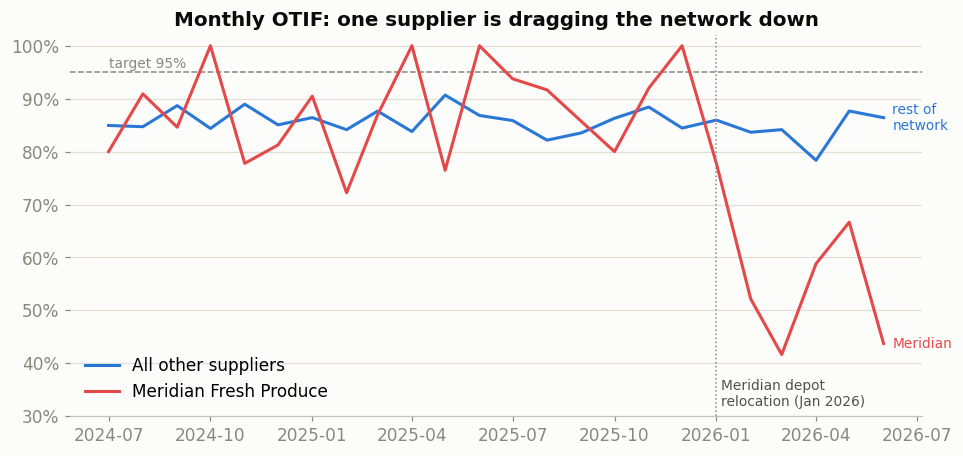

Meridian OTIF before Jan 2026: 87.5%   |   from Jan 2026: 57.4%


In [3]:
m_all  = df.groupby("order_month").is_otif.mean() * 100
mask   = df.supplier_name == "Meridian Fresh Produce"
m_mer  = df[mask].groupby("order_month").is_otif.mean() * 100
m_rest = df[~mask].groupby("order_month").is_otif.mean() * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axhline(95, color=MUTED, lw=1, ls="--")
ax.text(m_all.index[0], 95.8, "target 95%", color=MUTED, fontsize=9)
ax.plot(m_rest.index, m_rest.values, color=BLUE, lw=2, label="All other suppliers")
ax.plot(m_mer.index, m_mer.values, color=RED, lw=2, label="Meridian Fresh Produce")
ax.axvline(pd.Timestamp("2026-01-01"), color=MUTED, lw=1, ls=":")
ax.text(pd.Timestamp("2026-01-05"), 32, "Meridian depot\nrelocation (Jan 2026)", color=INK_2, fontsize=9)
ax.text(m_rest.index[-1] + pd.Timedelta(days=8), m_rest.values[-1], "rest of\nnetwork", color=BLUE, fontsize=9, va="center")
ax.text(m_mer.index[-1] + pd.Timedelta(days=8), m_mer.values[-1], "Meridian", color=RED, fontsize=9, va="center")
ax.set_title("Monthly OTIF: one supplier is dragging the network down")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(30, 102)
ax.legend(frameon=False, loc="lower left")
ax.grid(axis="x", visible=False)
fig.savefig("../images/otif_monthly_trend.png")
plt.show()

before = df[mask & (df.order_date < "2026-01-01")].is_otif.mean() * 100
after  = df[mask & (df.order_date >= "2026-01-01")].is_otif.mean() * 100
print(f"Meridian OTIF before Jan 2026: {before:.1f}%   |   from Jan 2026: {after:.1f}%")

The rest of the network is broadly stable in the mid-80s. **Meridian Fresh Produce falls
off a cliff in January 2026** — from 87.5% to 57.4% OTIF — coinciding with its depot
relocation. This single supplier explains most of the network-level deterioration in 2026.

## 3. Which suppliers drive the miss?

Failure counts are what matter for recovery effort, not OTIF % alone — a tiny supplier at
50% OTIF is a smaller prize than a huge one at 85%. Pareto of failed POs, last 12 months.

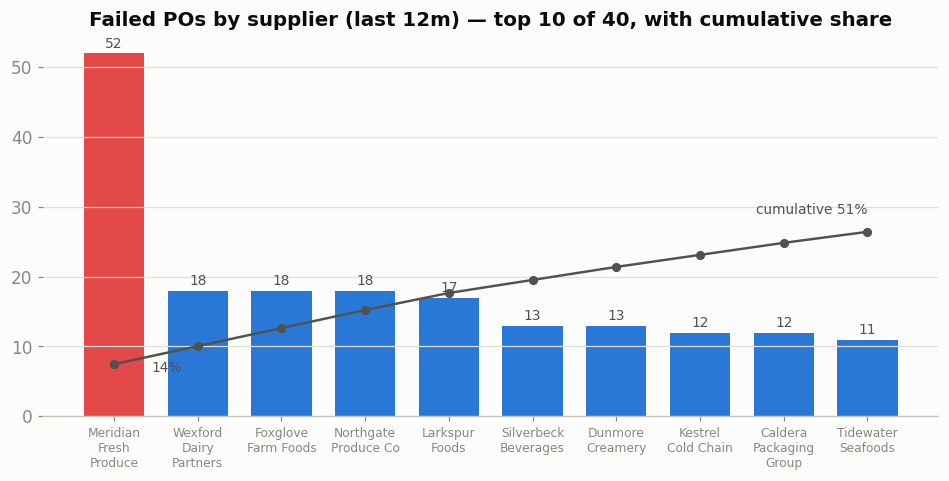

Meridian alone:  14.4% of all failed POs
Top 5 suppliers: 34.0% of all failed POs
Top 10:          50.8% of all failed POs


In [4]:
import textwrap

sup = (last12.groupby("supplier_name")
       .agg(fails=("is_otif", lambda s: int((1 - s).sum())), pos=("is_otif", "size"))
       .sort_values("fails", ascending=False))
sup["cum_pct"] = sup.fails.cumsum() / sup.fails.sum() * 100

top = sup.head(10)
fig, ax = plt.subplots(figsize=(10.5, 4.5))
colors = [RED if n == "Meridian Fresh Produce" else BLUE for n in top.index]
bars = ax.bar(range(len(top)), top.fails, color=colors, width=0.72)
for i, v in enumerate(top.fails):
    ax.text(i, v + 0.8, str(v), ha="center", color=INK_2, fontsize=9)
ax2 = ax.twinx()  # same x; axis hidden — the line carries only its two labels
ax2.plot(range(len(top)), top.cum_pct, color=INK_2, lw=1.6, marker="o", ms=5)
ax2.text(0.45, top.cum_pct.iloc[0] - 1, f"{top.cum_pct.iloc[0]:.0f}%",
         ha="left", va="center", color=INK_2, fontsize=9)
ax2.text(9, top.cum_pct.iloc[9] + 5, f"cumulative {top.cum_pct.iloc[9]:.0f}%",
         ha="right", color=INK_2, fontsize=9)
ax2.set_ylim(0, 105); ax2.axis("off")
ax.set_xticks(range(len(top)))
ax.set_xticklabels(["\n".join(textwrap.wrap(n, 11)) for n in top.index], fontsize=8)
ax.set_title("Failed POs by supplier (last 12m) — top 10 of 40, with cumulative share")
ax.grid(axis="x", visible=False)
fig.savefig("../images/supplier_pareto.png")
plt.show()

print(f"Meridian alone:  {sup.cum_pct.iloc[0]:.1f}% of all failed POs")
print(f"Top 5 suppliers: {sup.cum_pct.iloc[4]:.1f}% of all failed POs")
print(f"Top 10:          {sup.cum_pct.iloc[9]:.1f}% of all failed POs")

Classic concentration: **the top 5 suppliers account for a third of all failures, the top
10 for over half** — out of 40 active suppliers. Supplier recovery conversations can be
focused on a short list.

## 4. Failure modes — late vs short, by category

"We're missing OTIF" is not actionable. *How* POs fail, and where, is.

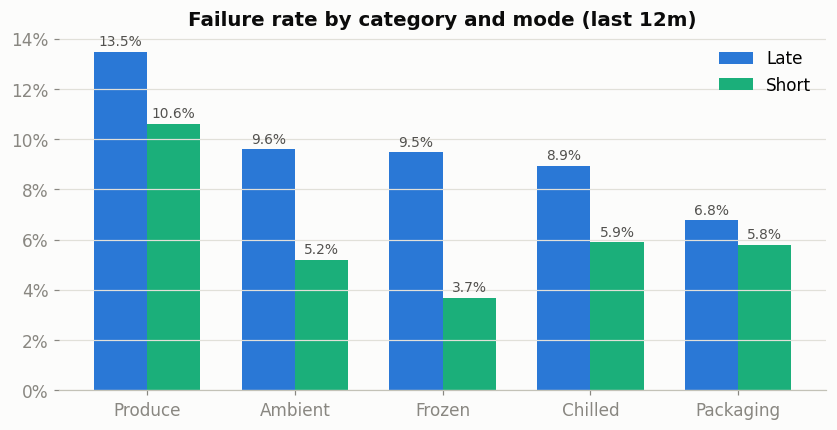

In [5]:
cat = (last12.groupby("category")
       .agg(late_pct=("is_late", "mean"), short_pct=("is_short", "mean"), pos=("is_late", "size")) * 100)
cat["pos"] = (cat.pos / 100).astype(int)
cat = cat.sort_values("late_pct", ascending=False)

x = np.arange(len(cat)); w = 0.36
fig, ax = plt.subplots(figsize=(9, 4.2))
b1 = ax.bar(x - w/2, cat.late_pct, w, color=BLUE, label="Late")
b2 = ax.bar(x + w/2, cat.short_pct, w, color=AQUA, label="Short")
for b in (*b1, *b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.25, f"{b.get_height():.1f}%", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(cat.index)
ax.set_title("Failure rate by category and mode (last 12m)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.savefig("../images/failure_modes.png")
plt.show()

**Produce is the problem category on both modes** — and it's the only category where
short-shipping rivals lateness (10.6% short vs ~4–6% everywhere else). That points at fill
/ field-availability issues with produce growers, not just logistics — a different
conversation than "deliver on time".

## 5. The Friday effect — is some of this *our* fault?

Late rate by scheduled delivery day. If lateness were purely a supplier problem it would be
flat across the week.

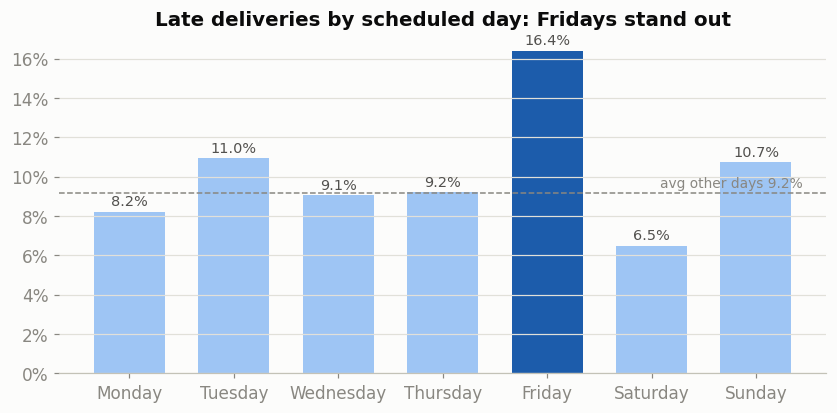

In [6]:
dow = last12.copy()
dow["day"] = dow.expected_delivery_date.dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = dow.groupby("day").is_late.mean().reindex(order) * 100

fig, ax = plt.subplots(figsize=(9, 4))
colors = [BLUE_DARK if d == "Friday" else BLUE_LIGHT for d in order]
bars = ax.bar(order, by_day.values, color=colors, width=0.68)
for b, v in zip(bars, by_day.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.1f}%", ha="center", color=INK_2, fontsize=9.5)
avg_rest = dow[dow.day != "Friday"].is_late.mean() * 100
ax.axhline(avg_rest, color=MUTED, lw=1, ls="--")
ax.text(6.45, avg_rest + 0.3, f"avg other days {avg_rest:.1f}%", color=MUTED, fontsize=9, ha="right")
ax.set_title("Late deliveries by scheduled day: Fridays stand out")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="x", visible=False)
fig.savefig("../images/late_by_weekday.png")
plt.show()

**Friday deliveries are ~1.8× more likely to be late than the rest of the week.** That
pattern is consistent with a receiving-capacity constraint on our side (Friday is the
heaviest inbound day before the weekend), not with supplier behaviour — suppliers don't
collectively get worse on one weekday. Rebalancing delivery slots is in our control and
free.

## 6. Stock accuracy — where do inventory records break down?

Cycle counts (12 months, 250 SKUs, monthly). Accuracy = counted qty exactly matches system
qty.

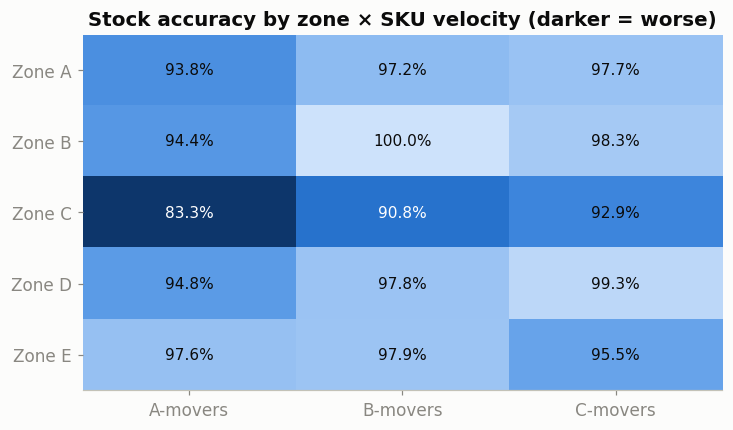

Overall stock accuracy: 95.7%  (target 98%)
Zone C:                 90.3%
Zone C, A-movers:       83.3%


In [7]:
acc = counts.assign(ok=(counts.counted_qty == counts.system_qty))
pivot = acc.pivot_table(index="zone", columns="velocity_class", values="ok", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(7.5, 4.2))
err = 100 - pivot  # plot inaccuracy so darker = worse
im = ax.imshow(err.values, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"]), aspect="auto")
for i in range(err.shape[0]):
    for j in range(err.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=10,
                color="white" if err.values[i, j] > 8 else INK)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f"{c}-movers" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([f"Zone {z}" for z in pivot.index])
ax.set_title("Stock accuracy by zone × SKU velocity (darker = worse)")
ax.grid(visible=False)
fig.savefig("../images/stock_accuracy_heatmap.png")
plt.show()

overall = acc.ok.mean() * 100
zc = acc[acc.zone == "C"].ok.mean() * 100
zca = acc[(acc.zone == "C") & (acc.velocity_class == "A")].ok.mean() * 100
print(f"Overall stock accuracy: {overall:.1f}%  (target 98%)")
print(f"Zone C:                 {zc:.1f}%")
print(f"Zone C, A-movers:       {zca:.1f}%")

The miss is **not spread evenly**: Zone C — the high-velocity pick face — sits at 90.3%,
and its fastest movers at **83.3%**, while most of the warehouse is at or near target.
Inventory record errors concentrate exactly where picking traffic is heaviest.

## Conclusions — what we'd do on Monday morning

1. **Meridian Fresh Produce recovery plan.** OTIF fell 87.5% → 57.4% after its Jan 2026
   depot relocation; it alone is 14% of all failed POs. Joint recovery plan with weekly
   review — this is the single biggest lever.
2. **Focus supplier management on the top 10.** They carry >50% of failures; the tail of
   30 suppliers is noise by comparison.
3. **Produce fill-rate programme.** Produce short-ships at ~2× the rate of any other
   category — order-quantity buffers or dual-sourcing for the worst growers.
4. **Rebalance Friday delivery slots.** ~1.8× late rate on Fridays points at our own
   receiving capacity; shifting volume to Mon/Wed/Sat is free OTIF.
5. **Targeted cycle counting in Zone C.** Count A-movers in Zone C weekly instead of
   monthly; that's where records break (83.3% accuracy vs 98% target).

**Estimated prize:** items 1, 2 and 4 together address roughly half of current OTIF
failures — enough to recover to the low 90s before touching the long tail.